In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\91834\Downloads\weatherAUS.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [4]:
df.shape

(142193, 24)

In [5]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='str')

In [6]:
df.dtypes

Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RISK_MM          float64
RainTomorrow         str
dtype: object

In [7]:
df.isna().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Date']=pd.to_datetime(df['Date'])   

In [10]:
df['year']= df['Date'].dt.year
df['year']

0         2008
1         2008
2         2008
3         2008
4         2008
          ... 
142188    2017
142189    2017
142190    2017
142191    2017
142192    2017
Name: year, Length: 142193, dtype: int32

In [11]:
df['month']=df['Date'].dt.month
df['month']

0         12
1         12
2         12
3         12
4         12
          ..
142188     6
142189     6
142190     6
142191     6
142192     6
Name: month, Length: 142193, dtype: int32

In [12]:
#eda part..check the data and understand before building the model..

df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

<Axes: xlabel='RainTomorrow'>

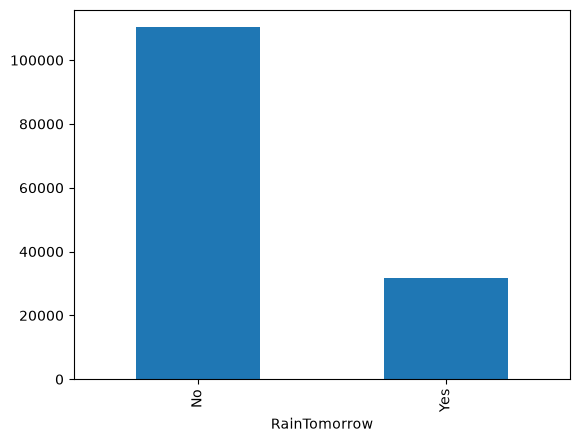

In [13]:
df['RainTomorrow'].value_counts().plot(kind='bar')

<Axes: xlabel='RainTomorrow', ylabel='Count'>

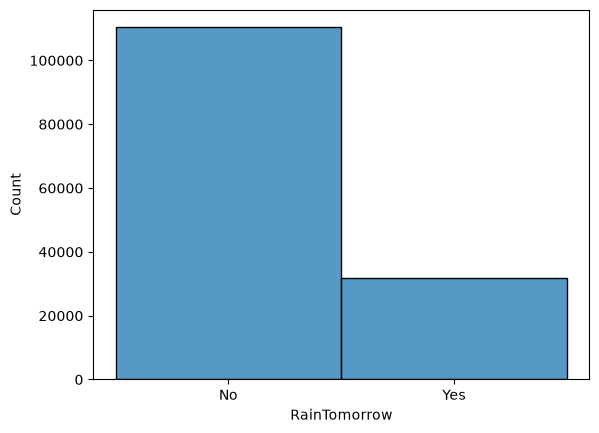

In [14]:
sns.histplot(x='RainTomorrow',data=df)

In [15]:
numerical = df.select_dtypes(include= np.number).columns

In [16]:
categorical=df.select_dtypes(exclude = np.number).columns

In [17]:
print(numerical)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RISK_MM', 'year', 'month'],
      dtype='str')


In [18]:
print(categorical)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


In [19]:
df[numerical].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM,year,month
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000,142193.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682,2012.758926,6.402544
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969,2.541256,3.426506
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000,2007.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,2011.000000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,2013.000000,6.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000,2015.000000,9.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000,2017.000000,12.000000


In [20]:
df[numerical].skew()

MinTemp          0.023900
MaxTemp          0.224917
Rainfall         9.888061
Evaporation      3.746834
Sunshine        -0.502911
WindGustSpeed    0.874305
WindSpeed9am     0.775494
WindSpeed3pm     0.631433
Humidity9am     -0.482821
Humidity3pm      0.034515
Pressure9am     -0.096211
Pressure3pm     -0.046198
Cloud9am        -0.224286
Cloud3pm        -0.224092
Temp9am          0.091387
Temp3pm          0.240054
RISK_MM          9.836902
year            -0.042629
month            0.028958
dtype: float64

<Axes: >

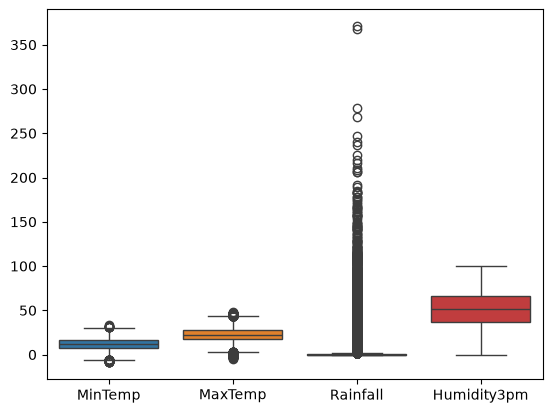

In [21]:
sns.boxplot(data=df[['MinTemp','MaxTemp','Rainfall','Humidity3pm']])

In [22]:
df[numerical].columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RISK_MM', 'year', 'month'],
      dtype='str')

In [23]:
df[categorical].columns

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [24]:
df.RainToday.value_counts()

RainToday
No     109332
Yes     31455
Name: count, dtype: int64

In [25]:
#bivariate analysis.
#for 2 varibales together..

#numerical + numerical = scatter plot
#numerical + categorical = box plot
#categorical + categorical = count plot

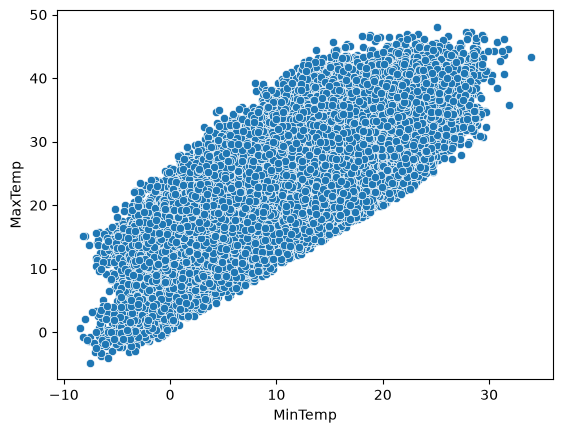

In [26]:
sns.scatterplot(x='MinTemp',y='MaxTemp',data=df)     #numerical + numerical
plt.show()

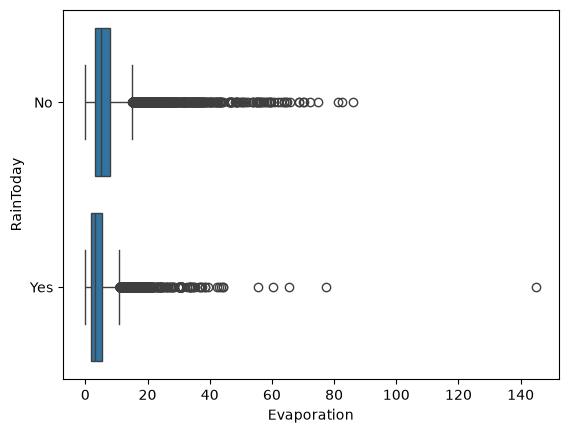

In [27]:
sns.boxplot(x='Evaporation',y='RainToday',data=df)   #numerical + categorical...
plt.show()

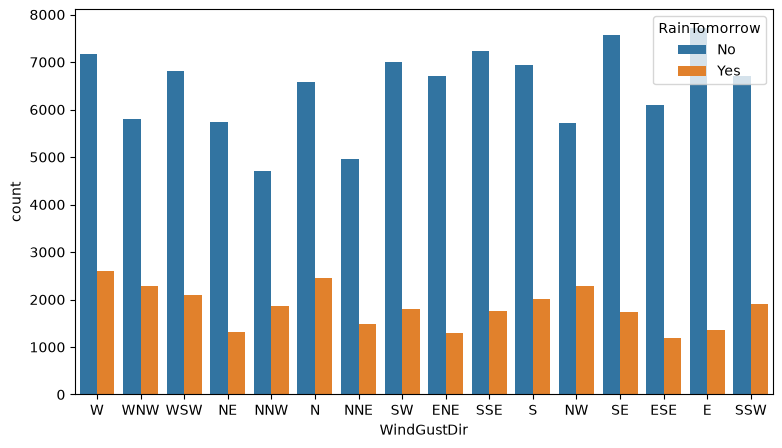

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(9,5))
sns.countplot(x='WindGustDir',hue='RainTomorrow',data=df)  #///# categorical + categorical (ccc)-> cate,cate,count..
plt.show()
plt.tight_layout()  #-> is for text data should look gud.

In [29]:
#target variable is RainTomorrow..

df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [66]:
X = df.drop('RainTomorrow',axis=1)
y = df['RainTomorrow']
numerical = X.select_dtypes(include=np.number).columns
categorical = X.select_dtypes(include='str').columns

In [67]:
#df = df.dropna(subset=['RainTomorrow'])

In [68]:
#train/test/split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
x_train.shape

y_train.shape

x_test.shape

y_test.shape


(28439,)

In [70]:
# fill missing values with median and mode..

for col in numerical:
    x_train[col] = x_train[col].fillna(x_train[col].median())
    x_test[col] = x_test[col].fillna(x_train[col].median())

In [71]:
for col in categorical:
    x_train[col] = x_train[col].fillna(x_train[col].mode()[0])
    x_test[col] = x_test[col].fillna(x_train[col].mode()[0])

In [72]:
print(x_train.isnull().sum().sum())
print(x_test.isnull().sum().sum())

0
0


In [73]:
print(x_train.isna().sum().sum())
print(x_test.isna().sum().sum())

0
0


In [62]:
x_train.shape

(113754, 25)

In [75]:
# encoding..

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

x_train = pd.get_dummies(x_train,columns = categorical,drop_first=True)
x_test = pd.get_dummies(x_test,columns = categorical, drop_first=True)


In [76]:
#align ..before and after some columns only  will be missing..so align to make eql..
x_test = x_test.reindex(columns=x_train.columns,fill_value=0)

In [77]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(113754, 114)
(113754,)
(28439, 114)
(28439,)


In [79]:
print(x_train.dtypes)

Date              datetime64[us]
MinTemp                  float64
MaxTemp                  float64
Rainfall                 float64
Evaporation              float64
                       ...      
WindDir3pm_SW               bool
WindDir3pm_W                bool
WindDir3pm_WNW              bool
WindDir3pm_WSW              bool
RainToday_Yes               bool
Length: 114, dtype: object


In [80]:
x_train = x_train.drop('Date',axis= 1)
x_test = x_test.drop('Date',axis = 1)

In [82]:
#standardscaler is used to make values in a scaler..like larger values..they use mean and std deviation..using formula...

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [83]:
# create model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [84]:
model.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [85]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(113754, 113)
(113754,)
(28439, 113)
(28439,)


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [95]:
#accuracy score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9998945110587574


In [96]:
#confusion matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_pred,y_test))

[[22022     3]
 [    0  6414]]


In [97]:
# classification report

from sklearn.metrics import classification_report


print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00     22025
         Yes       1.00      1.00      1.00      6414

    accuracy                           1.00     28439
   macro avg       1.00      1.00      1.00     28439
weighted avg       1.00      1.00      1.00     28439



In [98]:
from sklearn.metrics import roc_auc_score   #roc= reciever operating characteristic. #auc= area under curve.

In [99]:
y_prob = model.predict_proba(x_test)[:,1]  #uses 1 to get only one column bcz closer to 1 is better

In [100]:
print(roc_auc_score(y_test,y_prob))

0.9999993348201942


In [101]:
# k- fold validation.

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,x_train,y_train, cv=5,scoring = 'accuracy') 
print(scores)
print(scores.mean())

[0.99810997 0.9978902  0.99771439 0.99810997 0.99815385]
0.9979956762678226


In [102]:
from sklearn.model_selection import GridSearchCV

params = {'C':[0.01,0.1,1,10]}

grid = GridSearchCV ( model,params,cv=5,scoring = 'accuracy')

In [103]:
grid.fit(x_train,y_train)
print(grid.best_params_)
best_model = grid.best_estimator_

{'C': 10}


In [104]:
y_pred = best_model.predict(x_train)

In [91]:
y_pred

array(['No', 'No', 'No', ..., 'No', 'Yes', 'Yes'],
      shape=(113754,), dtype=object)

In [92]:
print(grid.best_score_)

0.9999472542928919


In [105]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.9998945110587574


In [106]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))

Final Test Accuracy: 0.9998945110587574
